# Detecção de Síndrome dos Ovários Policísticos (SOP/PCOS) com Machine Learning
### Tech Challenge — Fase 1 (Módulo de Machine Learning)

Este notebook constrói um modelo de Machine Learning capaz de
apoiar a detecção da Síndrome dos Ovários Policísticos (SOP) — em inglês, *PCOS* — a
partir de dados clínicos de pacientes.

## O problema

A SOP é um dos distúrbios hormonais mais comuns entre mulheres em idade reprodutiva.
Quando não diagnosticada, pode levar a complicações como infertilidade, diabetes e
doenças cardíacas. O diagnóstico, porém, depende de vários exames e da análise de um
especialista, o que torna a triagem precoce um desafio.

A proposta aqui é criar uma ferramenta de apoio à decisão médica: um modelo que,
a partir de exames e características da paciente, estima a probabilidade de SOP e ajuda
a priorizar quem precisa de investigação mais rápida. O modelo **não substitui o
médico** — ele apenas apoia a triagem.

## O dataset

- **Fonte:** [PCOS — Kaggle](https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos)
- **Arquivo:** `PCOS_data_without_infertility.xlsx`, aba **`Full_new`**
- Contém dados de ~541 pacientes com exames hormonais, medidas físicas e resultados de
  ultrassom. A coluna-alvo é **`PCOS (Y/N)`** (1 = tem SOP, 0 = não tem).

## O que fizemos (passo a passo)

1. Carga dos dados
2. Exploração (estatísticas, distribuição do alvo, correlações)
3. Pré-processamento (limpeza, conversão de tipos, valores ausentes)
4. Modelagem (3 modelos de classificação + separação treino/teste)
5. Avaliação (accuracy, recall, F1 e escolha da métrica)
6. Explicabilidade (feature importance + SHAP)
7. Discussão crítica

## 0. Preparação do ambiente

Aqui apenas importamos as bibliotecas que utilizei durante todo o projeto.
Se estiver rodando no Google Colab e faltar algum pacote, descomente a linha de `pip install`.

In [23]:
# Se algum pacote faltar (ex.: no Colab), descomente a linha abaixo:
# !pip install -q scikit-learn pandas numpy matplotlib seaborn shap openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, recall_score, f1_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, roc_auc_score)

# Deixa os gráficos mais bonitos e define um "random_state" para reprodutibilidade
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42   # fixa a aleatoriedade -> resultados sempre iguais a cada execução

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carga dos dados

O dataset vem em um arquivo Excel com várias abas. A aba com os dados completos é a
**`Full_new`**, então foi ela que carreguei.

In [24]:
# Caminho do arquivo (deve estar na mesma pasta do notebook)
ARQUIVO = "../datasets/PCOS_data_without_infertility.xlsx"

# Lemos a aba "Full_new", que contém os dados completos
df = pd.read_excel(ARQUIVO, sheet_name="Full_new")

print(f"Dados carregados: {df.shape[0]} pacientes e {df.shape[1]} colunas.")
df.head()

Dados carregados: 541 pacientes e 45 colunas.


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


## 2. Exploração dos dados (EDA)

Antes de modelar, precisei entender os dados: quantas colunas tinha, quais os tipos,
se existem valores ausentes, como o alvo está distribuído e quais variáveis mais se
relacionam com a SOP.

In [25]:
# Visão geral: tipos de dados e valores não-nulos de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [26]:
# Estatísticas descritivas das colunas numéricas (média, desvio, mínimo, máximo...)
# Mostra apenas as 10 primeiras para não poluir a tela.
df.describe().T.head(10).round(2)

,count,mean,std,min,25%,50%,75%,max
Sl. No,541.0,271.00,156.32,1.00,136.00,271.00,406.00,541.0
Patient File No.,541.0,271.00,156.32,1.00,136.00,271.00,406.00,541.0
PCOS (Y/N),541.0,0.33,0.47,0.00,0.00,0.00,1.00,1.0
Age (yrs),541.0,31.43,5.41,20.00,28.00,31.00,35.00,48.0
Weight (Kg),541.0,59.64,11.03,31.00,52.00,59.00,65.00,108.0
Height(Cm),541.0,156.48,6.03,137.00,152.00,156.00,160.00,180.0
BMI,541.0,24.31,4.06,12.42,21.64,24.24,26.63,38.9
Blood Group,541.0,13.80,1.84,11.00,13.00,14.00,15.00,18.0
Pulse rate(bpm),541.0,73.25,4.43,13.00,72.00,72.00,74.00,82.0
RR (breaths/min),541.0,19.24,1.69,16.00,18.00,18.00,20.00,28.0


### 2.1 Distribuição do alvo

Verificar como as classes estão distribuídas é essencial. Se houver desbalanceamento
(muito mais casos de uma classe do que da outra), a métrica accuracy pode enganar, e
precisa tomar cuidado na avaliação.

Contagem por classe (0 = Não tem SOP, 1 = Tem SOP):
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64 

Proporção (%):
PCOS (Y/N)
0    67.3
1    32.7
Name: proportion, dtype: float64


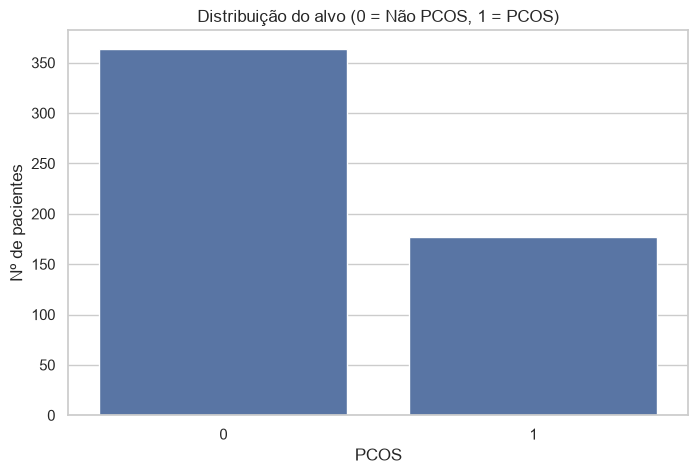

In [27]:
TARGET = "PCOS (Y/N)"   # nome da coluna-alvo

# Contagem e proporção de cada classe
contagem = df[TARGET].value_counts()
proporcao = df[TARGET].value_counts(normalize=True).mul(100).round(1)

print("Contagem por classe (0 = Não tem SOP, 1 = Tem SOP):")
print(contagem, "\n")
print("Proporção (%):")
print(proporcao)

# Gráfico de barras da distribuição
sns.countplot(x=df[TARGET])
plt.title("Distribuição do alvo (0 = Não PCOS, 1 = PCOS)")
plt.xlabel("PCOS"); plt.ylabel("Nº de pacientes")
plt.show()

**Leitura:** cerca de 1/3 das pacientes têm SOP (classe 1) e 2/3 não têm. É um
desbalanceamento moderado. Por isso, mais adiante, usei `stratify` na divisão
treino/teste (para manter essa proporção) e dei atenção especial ao **Recall** e ao **F1**,
e não só à accuracy.

### 2.2 Análise de correlação

A correlação mede o quanto duas variáveis "andam juntas". Aqui quis ver quais exames
e características mais se relacionam com a presença de SOP — isso ajuda a validar se os
dados fazem sentido do ponto de vista clínico.

> Observação: a coluna alvo já é numérica e algumas colunas ainda estão como texto.
> Fiz a análise de correlação de forma completa depois da limpeza (seção 3),
> mas já dei uma primeira olhada aqui.

In [28]:
# Correlação de cada coluna numérica com o alvo (em valor absoluto)
corr = df.corr(numeric_only=True)
corr_alvo = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)

print("Top 10 variáveis mais correlacionadas com PCOS:")
print(corr_alvo.head(10).round(3))

Top 10 variáveis mais correlacionadas com PCOS:
Follicle No. (R)        0.648
Follicle No. (L)        0.603
Skin darkening (Y/N)    0.476
hair growth(Y/N)        0.465
Weight gain(Y/N)        0.441
Cycle(R/I)              0.402
Fast food (Y/N)         0.378
Pimples(Y/N)            0.286
Weight (Kg)             0.212
BMI                     0.200
Name: PCOS (Y/N), dtype: float64


## 3. Pré-processamento (limpeza)

Dados reais quase nunca vêm prontos. Nesta etapa fiz o seguinte:

1. Limpar os nomes das colunas (remover espaços extras);
2. Remover colunas inúteis (números de identificação e uma coluna vazia);
3. Converter para número as colunas de exame que vieram como texto por engano;
4. Preencher valores ausentes usando a mediana de cada coluna.

Usei a mediana (e não a média) porque ela é mais robusta a valores extremos
(*outliers*), comuns em exames hormonais.

In [29]:
linhas0, cols0 = df.shape

# 3.1 Remover espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# 3.2 Remover colunas que não ajudam a prever:
#     - "Sl. No" e "Patient File No." são apenas identificadores
#     - "Unnamed: 44" é uma coluna vazia
cols_remover = ["Sl. No", "Patient File No.", "Unnamed: 44"]
df = df.drop(columns=[c for c in cols_remover if c in df.columns], errors="ignore")

# 3.3 Converter para número as colunas de exame que vieram como texto.
#     errors="coerce" transforma valores inválidos (ex.: digitação errada) em NaN.
cols_corrigir = ["II    beta-HCG(mIU/mL)", "AMH(ng/mL)"]
for col in cols_corrigir:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 3.4 Preencher valores ausentes com a MEDIANA de cada coluna
df = df.fillna(df.median(numeric_only=True))

print(f"Antes: {linhas0} linhas x {cols0} colunas")
print(f"Depois: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Valores ausentes restantes: {int(df.isna().sum().sum())}")
print(f"Colunas de texto restantes: {len(df.select_dtypes(include='object').columns)}")

Antes: 541 linhas x 45 colunas
Depois: 541 linhas x 42 colunas
Valores ausentes restantes: 0
Colunas de texto restantes: 0


### 3.1 Mapa de correlação (heatmap)

Agora que os dados estão limpos e todos numéricos, pude visualizar as correlações
entre as principais variáveis e o alvo em um único gráfico.

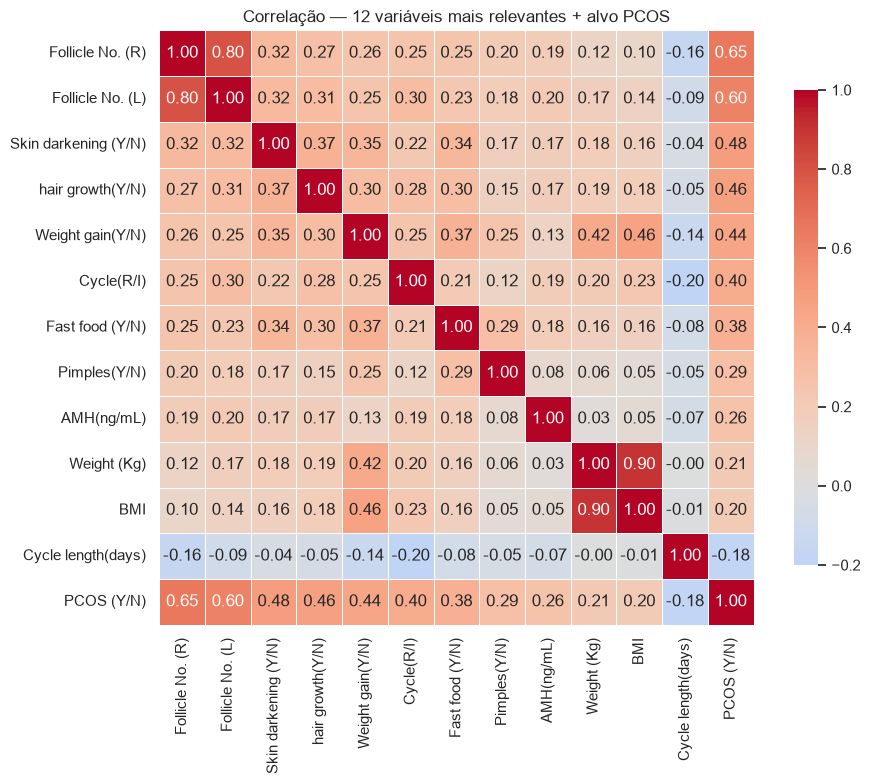

In [30]:
# Pegamos as 12 variáveis mais correlacionadas com o alvo + o próprio alvo
corr = df.corr(numeric_only=True)
top_feats = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12).index.tolist()
top_feats = top_feats + [TARGET]

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_feats].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlação — 12 variáveis mais relevantes + alvo PCOS")
plt.tight_layout()
plt.show()

**Leitura:** variáveis como o número de folículos (nos dois ovários), o ganho de peso,
a irregularidade do ciclo menstrual e o escurecimento da pele aparecem entre as mais
correlacionadas com a SOP — exatamente o que se espera do quadro clínico da doença. Isso é
um bom sinal de que os dados são coerentes.

## 4. Modelagem

### 4.1 Separação treino / teste

Separei os dados em treino (para o modelo aprender) e teste (para avaliar em dados
que ele nunca viu). Usei:

- `test_size=0.2` → 20% dos dados para teste;
- `stratify=y` → mantém a mesma proporção de SOP nos dois conjuntos (importante por causa
  do desbalanceamento).

In [31]:
# X = variáveis de entrada (todas menos o alvo); y = alvo
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Treino: {X_train.shape[0]} pacientes | Teste: {X_test.shape[0]} pacientes")
print(f"% de SOP no treino: {y_train.mean()*100:.1f}% | no teste: {y_test.mean()*100:.1f}%")

Treino: 432 pacientes | Teste: 109 pacientes
% de SOP no treino: 32.6% | no teste: 33.0%


### 4.2 Treinando os modelos

Comparei três algoritmos de classificação bem conhecidos:

- Regressão Logística — simples e fácil de interpretar;
- Random Forest — combina muitas árvores de decisão, costuma ter boa performance;
- KNN (K-vizinhos mais próximos) — classifica olhando os pacientes mais parecidos.

Cada modelo é colocado dentro de um `Pipeline` com um `StandardScaler`, que padroniza a
escala das variáveis. Usar o scaler dentro do pipeline garante que ele aprenda a escala
apenas com os dados de treino, evitando o *data leakage* (vazamento de informação do
teste para o treino).

In [32]:
def criar_pipeline(modelo):
    """Junta o padronizador (StandardScaler) com o modelo em um único Pipeline."""
    return Pipeline([("scaler", StandardScaler()), ("model", modelo)])

# Dicionário com os 3 modelos que vamos comparar
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

# Treina e avalia cada modelo, guardando os resultados
resultados = {}
for nome, modelo in modelos.items():
    pipe = criar_pipeline(modelo)
    pipe.fit(X_train, y_train)                 # treina
    y_pred = pipe.predict(X_test)              # prevê no teste
    y_proba = pipe.predict_proba(X_test)[:, 1] # probabilidade da classe "tem SOP"

    resultados[nome] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "pipe": pipe, "pred": y_pred, "proba": y_proba,
    }
    print(f"{nome:22s} -> Accuracy={resultados[nome]['Accuracy']:.3f} | "
          f"Recall={resultados[nome]['Recall']:.3f} | F1={resultados[nome]['F1']:.3f}")

Regressão Logística    -> Accuracy=0.890 | Recall=0.861 | F1=0.838
Random Forest          -> Accuracy=0.899 | Recall=0.778 | F1=0.836
KNN                    -> Accuracy=0.899 | Recall=0.722 | F1=0.825


## 5. Avaliação e escolha da métrica

### Qual métrica priorizar?

Em um problema de diagnóstico médico, nem todos os erros têm o mesmo peso:

- **Falso Negativo (FN):** dizer que a paciente NÃO tem SOP quando ela TEM.
  → É o erro mais grave: um diagnóstico perdido.
- **Falso Positivo (FP):** dizer que tem SOP quando não tem.
  → Menos grave: leva a exames extras, mas não deixa a doença passar.

Por isso, priorizei o **Recall** da classe positiva (proporção de pacientes com SOP que o
modelo consegue identificar) e usei o **F1** como equilíbrio entre Recall e Precision.
A **accuracy** sozinha pode enganar quando as classes estão desbalanceadas.

Relembrando as fórmulas:
- Accuracy = acertos totais ÷ total de casos
- Precision = TP ÷ (TP + FP) → das que o modelo disse "tem SOP", quantas realmente têm
- Recall = TP ÷ (TP + FN) → das que realmente têm SOP, quantas o modelo achou
- F1 = média harmônica entre Precision e Recall

                     Accuracy  Precision  Recall     F1    AUC
Regressão Logística     0.890      0.816   0.861  0.838  0.951
Random Forest           0.899      0.903   0.778  0.836  0.948
KNN                     0.899      0.963   0.722  0.825  0.937


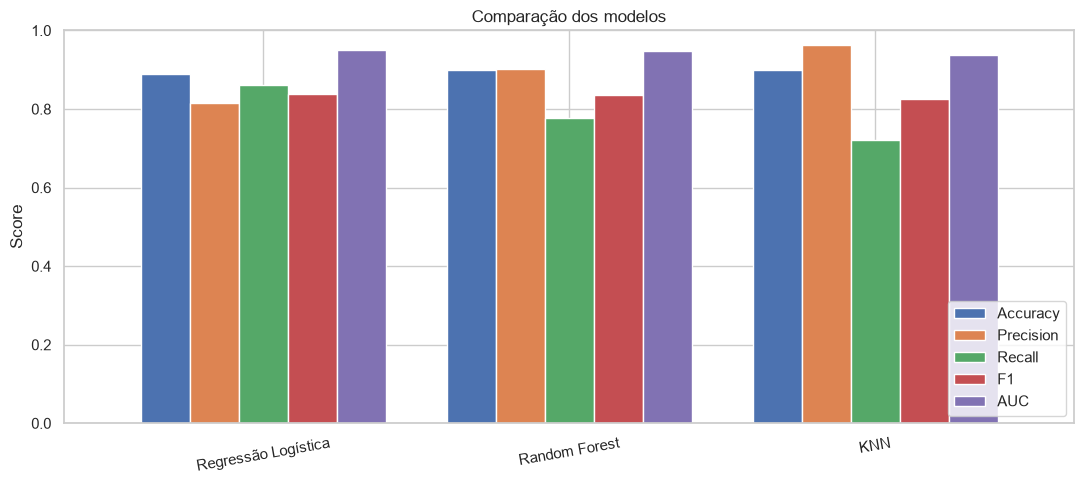

In [33]:
# Monta uma tabela comparativa e ordena por Recall (e depois F1)
metricas = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
tabela = pd.DataFrame(
    {nome: {m: resultados[nome][m] for m in metricas} for nome in resultados}
).T
tabela = tabela.sort_values(["Recall", "F1"], ascending=False).round(3)
print(tabela.to_string())

# Gráfico comparativo
tabela[metricas].plot(kind="bar", figsize=(11, 5), width=0.8)
plt.title("Comparação dos modelos"); plt.ylabel("Score"); plt.ylim(0, 1)
plt.xticks(rotation=10); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 5.1 Matriz de confusão e curva ROC

A matriz de confusão mostra os acertos e erros de cada tipo. O que busquei, principalmente, foi ter,
poucos Falsos Negativos (canto inferior esquerdo). A curva ROC resume a capacidade
de cada modelo de separar as duas classes — quanto mais próxima do canto superior esquerdo,
melhor.

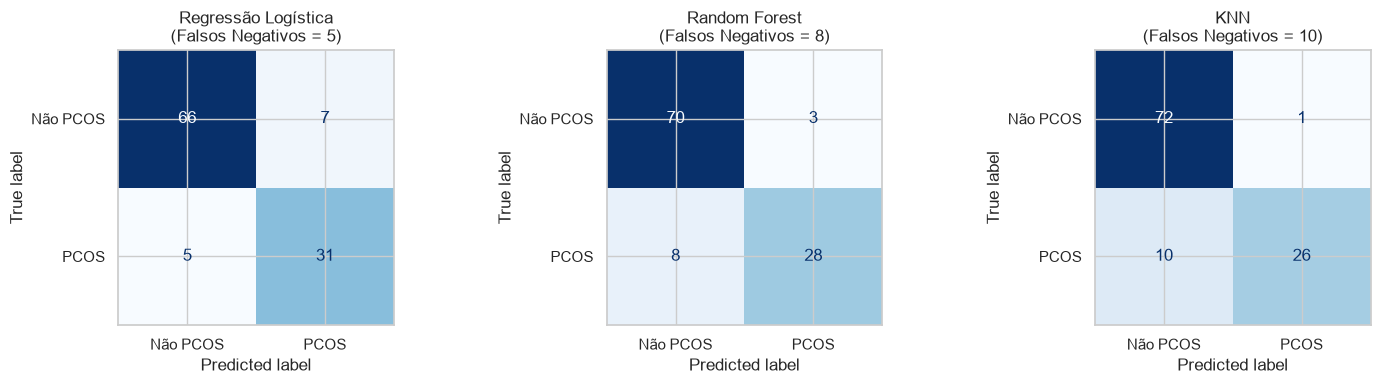

In [34]:
# Matrizes de confusão dos 3 modelos, lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nome in zip(axes, resultados):
    cm = confusion_matrix(y_test, resultados[nome]["pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Não PCOS", "PCOS"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    fn = cm[1, 0]  # real = PCOS, previsto = Não  -> falso negativo
    ax.set_title(f"{nome}\n(Falsos Negativos = {fn})")
plt.tight_layout(); plt.show()

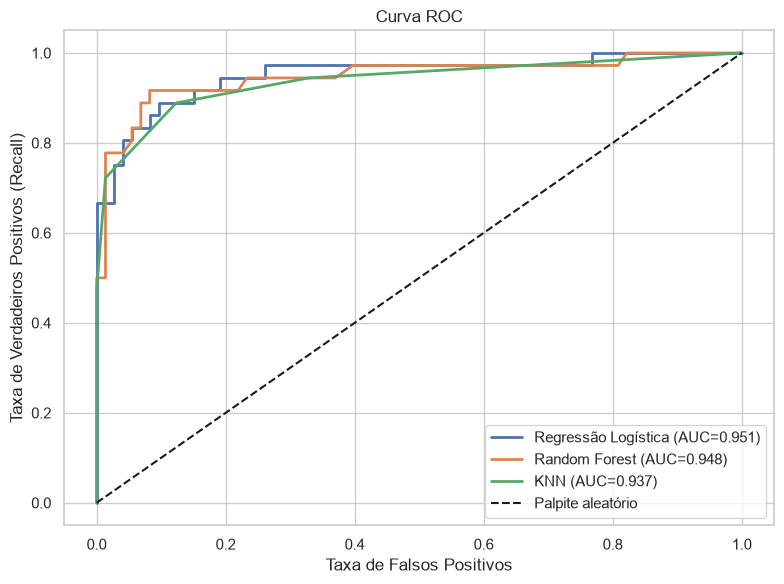

In [35]:
# Curva ROC dos 3 modelos
plt.figure(figsize=(8, 6))
for nome in resultados:
    fpr, tpr, _ = roc_curve(y_test, resultados[nome]["proba"])
    plt.plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC={resultados[nome]['AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Palpite aleatório")
plt.xlabel("Taxa de Falsos Positivos"); plt.ylabel("Taxa de Verdadeiros Positivos (Recall)")
plt.title("Curva ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 5.2 Escolha do modelo final

Escolhi como modelo final aquele com o maior Recall (prioridade em não deixar passar
casos de SOP). Em caso de empate, o F1 desempata. Abaixo mostro o relatório completo de
classificação desse modelo.

In [36]:
# Escolhe o melhor modelo pelo Recall (primeiro da tabela já ordenada)
modelo_final_nome = tabela.index[0]
modelo_final = resultados[modelo_final_nome]["pipe"]
y_pred_final = resultados[modelo_final_nome]["pred"]

print(f"Modelo final escolhido: {modelo_final_nome}\n")
print(classification_report(y_test, y_pred_final,
                            target_names=["Não PCOS (0)", "PCOS (1)"]))

Modelo final escolhido: Regressão Logística

              precision    recall  f1-score   support

Não PCOS (0)       0.93      0.90      0.92        73
    PCOS (1)       0.82      0.86      0.84        36

    accuracy                           0.89       109
   macro avg       0.87      0.88      0.88       109
weighted avg       0.89      0.89      0.89       109



## 6. Explicabilidade

Em saúde, não basta o modelo acertar — é preciso entender por quê ele decide de certa
forma. Isso torna o modelo auditável e ajuda o médico a confiar (ou desconfiar) da
sugestão. Utilizei duas técnicas:

1. Feature Importance — visão global de quais variáveis o modelo mais usa;
2. SHAP — explica a contribuição de cada variável, inclusive por paciente.

### 6.1 Feature Importance

Se o modelo final for uma Random Forest, utilizei a importância das variáveis calculada
pela própria árvore. Se for um modelo linear (Regressão Logística), utilizei o valor
absoluto dos coeficientes como medida de importância.

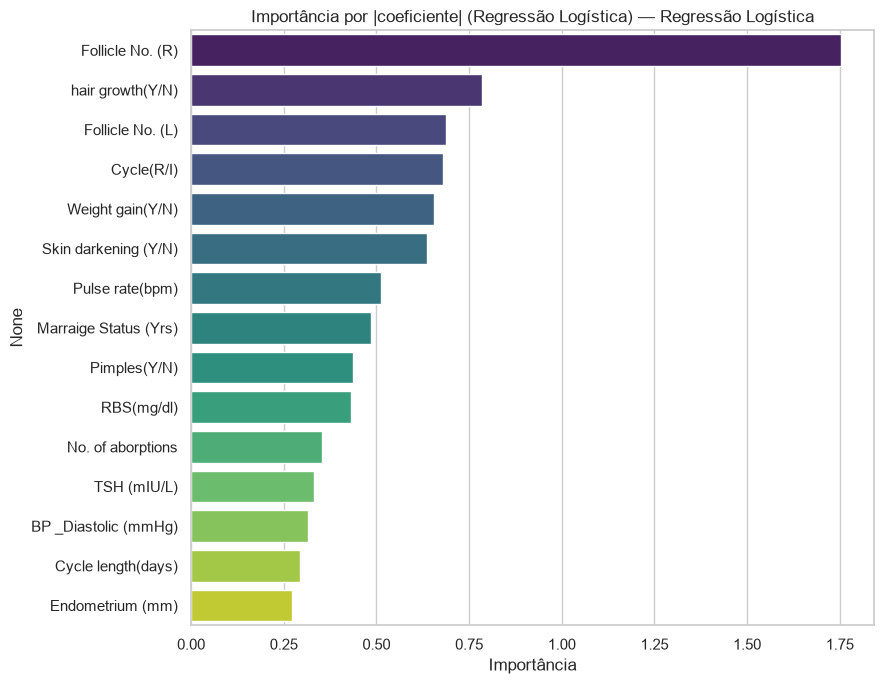

Top 5 variáveis mais influentes:
Follicle No. (R)    1.755
hair growth(Y/N)    0.785
Follicle No. (L)    0.686
Cycle(R/I)          0.678
Weight gain(Y/N)    0.656
dtype: float64


In [37]:
modelo_step = modelo_final.named_steps["model"]

if hasattr(modelo_step, "feature_importances_"):
    # Modelos de árvore (Random Forest) têm feature_importances_
    importancia = pd.Series(modelo_step.feature_importances_, index=X.columns)
    titulo = "Feature Importance (Random Forest)"
else:
    # Modelos lineares: usamos o |coeficiente| como importância
    importancia = pd.Series(np.abs(modelo_step.coef_[0]), index=X.columns)
    titulo = "Importância por |coeficiente| (Regressão Logística)"

top15 = importancia.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top15.values, y=top15.index, hue=top15.index,
            palette="viridis", legend=False)
plt.title(f"{titulo} — {modelo_final_nome}")
plt.xlabel("Importância"); plt.tight_layout(); plt.show()

print("Top 5 variáveis mais influentes:")
print(top15.head(5).round(3))

**Leitura:** se variáveis como número de folículos, AMH (hormônio anti-mülleriano),
ganho de peso e irregularidade do ciclo aparecem no topo, é um ótimo sinal — são
justamente os fatores associados à SOP na prática clínica. O modelo aprendeu padrões
coerentes, e não "atalhos" sem sentido.

### 6.2 SHAP

O **SHAP** (*SHapley Additive exPlanations*) atribui a cada variável um valor que indica
o quanto ela empurrou a previsão para "tem SOP" ou "não tem SOP", em cada paciente.
O gráfico de resumo (*summary plot*) junta essa informação de todas as pacientes do teste.

Background dataset has 109 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=109 when initializing the masker.


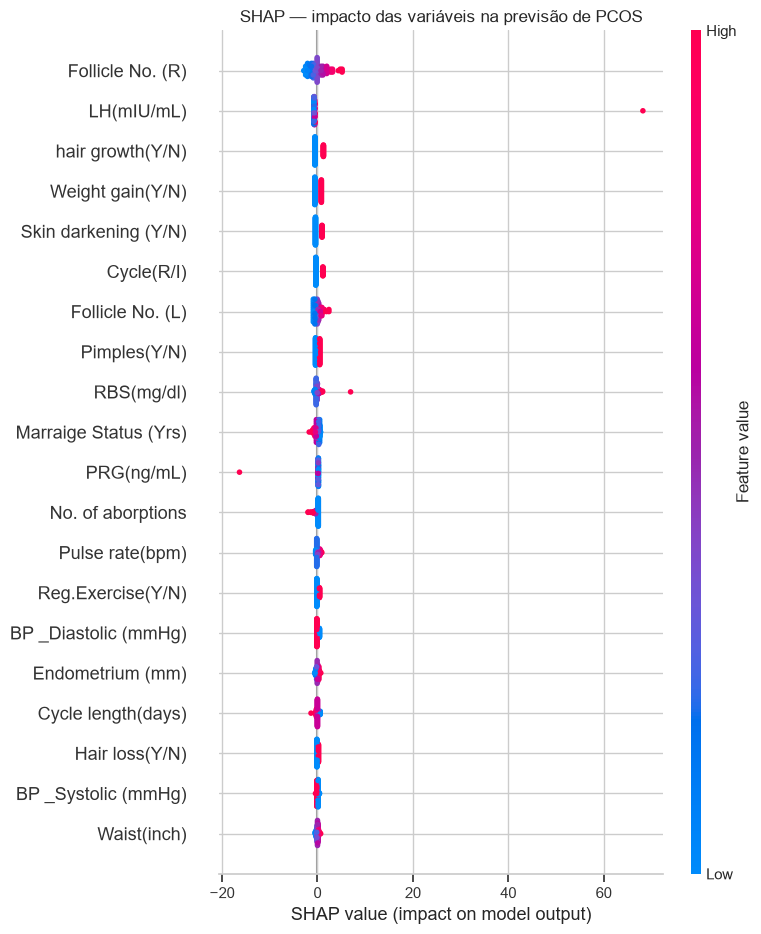

In [38]:
import shap

modelo_step = modelo_final.named_steps["model"]

# Escolhemos o explainer conforme o tipo do modelo final
if hasattr(modelo_step, "feature_importances_"):
    # Modelo de árvore -> TreeExplainer (usa os dados originais)
    explainer = shap.TreeExplainer(modelo_step)
    X_exp = X_test
else:
    # Modelo linear -> LinearExplainer (usa os dados já escalonados pelo pipeline)
    scaler = modelo_final.named_steps["scaler"]
    X_exp = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
    explainer = shap.LinearExplainer(modelo_step, X_exp)

shap_values = explainer.shap_values(X_exp)

# Garante que estamos olhando a classe positiva (PCOS = 1),
# compatível com diferentes versões do SHAP.
if isinstance(shap_values, list):
    shap_pcos = shap_values[1]
elif hasattr(shap_values, "ndim") and shap_values.ndim == 3:
    shap_pcos = shap_values[:, :, 1]
else:
    shap_pcos = shap_values

shap.summary_plot(shap_pcos, X_exp, show=False)
plt.title("SHAP — impacto das variáveis na previsão de PCOS")
plt.tight_layout(); plt.show()

**Como ler o gráfico SHAP:**
- Cada ponto é uma paciente. Pontos à direita empurram a previsão para "tem SOP";
  pontos à esquerda, para "não tem".
- A cor indica o valor da variável: vermelho = valor alto, azul = valor baixo.
- Exemplo típico: muitos folículos (vermelho) aparecem à direita → aumentam a probabilidade
  de SOP. Isso confirma, de forma visual e por paciente, o que vimos na feature importance.

## 7. Discussão crítica

**O modelo pode ser usado na prática? Como?**
Sim — mas como ferramenta de apoio / triagem, e não como decisor final. Ele pode
priorizar pacientes com maior probabilidade de SOP para uma investigação mais rápida,
ajudando a acelerar o atendimento em locais com grande volume de pacientes.

**Por que priorizamos o Recall?**
Porque o erro mais grave neste contexto é o falso negativo — deixar de identificar uma
paciente que realmente tem SOP. Um recall alto reduz esse risco. O F1 nos garante que isso
não vem ao custo de "chutar SOP para todo mundo".

**Por que a explicabilidade importa?**
As técnicas de Feature Importance e SHAP tornam a decisão transparente e auditável.
O médico consegue ver quais fatores levaram à sugestão do modelo e comparar com seu
próprio julgamento clínico, o que aumenta a confiança na ferramenta.

**Limite ético — o médico tem a palavra final.**
Este é um sistema de apoio. O diagnóstico definitivo é sempre responsabilidade do
profissional de saúde. O modelo não substitui exames, avaliação clínica nem o julgamento
médico.

**Limitações e próximos passos.**
- O dataset é relativamente pequeno (~541 pacientes) e vem de uma origem específica, o
  que limita a generalização.
- Antes de qualquer uso real, seria necessária validação externa com dados de outras
  populações e hospitais.
- Possíveis melhorias: coletar mais dados, ajustar hiperparâmetros, testar o ajuste do
  limiar de decisão para aumentar ainda mais o Recall, e monitorar o modelo ao longo do
  tempo.